# 7.3 Cross-Source — Sentiment & Emotions

**Input:** Newspapers, Polymarket, Financials, Bluesky  
**Output:** Sentiment × odds, emotions × markets, NRC profiles

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Newspaper Sentiment × Polymarket Odds](#1-newspaper-sentiment--polymarket-odds)
- [2. Newspaper Emotions × Financial Markets](#2-newspaper-emotions--financial-markets)
- [3. NRC 8-Emotion Profile — Bluesky](#3-nrc-8-emotion-profile--bluesky)
- [4. NRC 8-Emotion Profile — News](#4-nrc-8-emotion-profile--news)


## Setup

In [27]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

import house_style as _hs
importlib.reload(_hs)  # force reload — voorkomt stale __pycache__ versie

from house_style import (
    apply_style,
    REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    PALETTE,
    EVENTS,
    add_events, event_legend_handles,
    C_VIX, C_SP500,
    C_FEAR, C_ANGER, C_TRUST, C_DISGUST, C_SADNESS, C_JOY, C_ANTICIPATION,
    BLUESKY_BLUE, REDDIT_ORG,
)
apply_style()



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BRONZE = Path('../../Data/1_Bronze')
SILVER = Path('../../Data/2_Silver')

# ── Colour aliases ─────────────────────────────────────────────────────────
C_TRUMP  = REPUBLICAN
C_HARRIS = DEMOCRAT
C_DEM    = DEMOCRAT
C_REP    = REPUBLICAN
C_CEN    = NEUTRAL
C_MARKET = '#2ec4b6'
C_POLL   = '#9b5de5'

EVENT_DATES = [pd.Timestamp(date) for _, date, _ in EVENTS]

In [28]:
# ── Newspaper features ────────────────────────────────────────────────────────────
nlp  = pd.read_csv(SILVER / 'Newspapers/nlp_features_newspapers.csv',  parse_dates=['date'])
sent = pd.read_csv(SILVER / 'Newspapers/sentiment_features_newspapers.csv', parse_dates=['date'])

news = nlp.merge(sent, on='date', how='outer').sort_values('date').reset_index(drop=True)

# ── MediaCloud article-level → daily coverage metrics ────────────────────────
mc_raw = pd.read_csv(SILVER / 'Newspapers/mediacloud_articles_clean.csv', parse_dates=['date'])
mc_raw['mentions_trump']  = mc_raw['title_clean'].str.contains(r'\btrump\b',  case=False, na=False)
mc_raw['mentions_harris'] = mc_raw['title_clean'].str.contains(r'\bharris\b', case=False, na=False)

mc = (mc_raw.groupby('date')
     .agg(
         total_coverage   = ('title_clean', 'count'),
         n_trump_total    = ('mentions_trump',  'sum'),
         n_harris_total   = ('mentions_harris', 'sum'),
     )
     .reset_index())

denom = (mc['n_trump_total'] + mc['n_harris_total']).replace(0, float('nan'))
mc['trump_share']      = mc['n_trump_total'] / denom
mc['total_coverage_7d'] = mc['total_coverage'].rolling(7, min_periods=3).mean()
mc['trump_share_7d']    = mc['trump_share'].rolling(7,    min_periods=3).mean()

news = news.merge(mc, on='date', how='left')
print(f'Newspaper features : {news.shape}  ({news["date"].min().date()} → {news["date"].max().date()})')

Newspaper features : (118, 94)  (2024-07-05 → 2024-11-04)


In [29]:
# ── Polymarket odds ───────────────────────────────────────────────────────────────
poly = pd.read_csv(BRONZE / 'polymarket/polymarket_win_probabilities.csv',
                    parse_dates=['date'])
poly.columns = ['date', 'trump_odds', 'harris_odds']
poly = poly.sort_values('date').reset_index(drop=True)
print(f'Polymarket         : {poly.shape}  ({poly["date"].min().date()} → {poly["date"].max().date()})')
poly.head(3)

Polymarket         : (128, 3)  (2024-07-01 → 2024-11-05)


,date,trump_odds,harris_odds
0,2024-07-01,66.0,4.45
1,2024-07-02,65.0,9.65
2,2024-07-03,61.5,15.50


In [30]:
# ── Wikipedia polls → 7-day rolling average margin ─────────────────────────
polls_raw = pd.read_csv(BRONZE / 'polls/wikipedia_polls.csv')

# Parse numeric Trump/Harris support
for col in ['Trump', 'Harris']:
    polls_raw[col] = (
        polls_raw[col]
        .astype(str)
        .str.extract(r'([\d.]+)')[0]
        .astype(float)
    )

polls_raw['Date'] = pd.to_datetime(polls_raw['Date'], errors='coerce')
polls_raw = polls_raw.dropna(subset=['Date', 'Trump', 'Harris'])
polls_raw['margin'] = polls_raw['Trump'] - polls_raw['Harris']   # positive = Trump leads

# Daily average (multiple polls on same day)
daily_polls = (
    polls_raw.groupby('Date')[['Trump', 'Harris', 'margin']]
    .mean()
    .reset_index()
    .rename(columns={'Date': 'date', 'Trump': 'poll_trump', 'Harris': 'poll_harris'})
)

# Interpolate to full daily index, then smooth with 7-day rolling mean
date_idx = pd.date_range(daily_polls['date'].min(), daily_polls['date'].max(), freq='D')
daily_polls = (
    daily_polls.set_index('date')
    .reindex(date_idx)
    .interpolate('linear')
    .reset_index()
    .rename(columns={'index': 'date'})
)
daily_polls['poll_trump_7d']   = daily_polls['poll_trump'].rolling(7,  min_periods=1).mean()
daily_polls['poll_harris_7d']  = daily_polls['poll_harris'].rolling(7, min_periods=1).mean()
daily_polls['poll_margin_7d']  = daily_polls['margin'].rolling(7,      min_periods=1).mean()

print(f'Polls (daily interp): {daily_polls.shape}  ({daily_polls["date"].min().date()} → {daily_polls["date"].max().date()})')

Polls (daily interp): (134, 7)  (2024-06-24 → 2024-11-04)


In [31]:
# ── Financial market data ──────────────────────────────────────────────────────────
fin = pd.read_csv(BRONZE / 'financials/market.csv', parse_dates=['Date'])
fin = fin.rename(columns={'Date': 'date'})
fin = fin.sort_values('date').reset_index(drop=True)
print(f'Financials         : {fin.shape}  ({fin["date"].min().date()} → {fin["date"].max().date()})')

Financials         : (108, 6)  (2024-06-03 → 2024-11-04)


In [32]:
# ── Google Trends ──────────────────────────────────
gt = pd.read_csv(BRONZE / 'google_trends/trends_daily_stitched.csv', parse_dates=['date'])
gt = gt.sort_values('date').reset_index(drop=True)

gt = gt.rename(columns={
    'trump':         'gt_trump',
    'kamala':        'gt_kamala',
    'biden':         'gt_biden',
    'elon musk':     'gt_elon',
    'election 2024': 'gt_election',
    'vote':          'gt_vote',
    'conspiracy':    'gt_conspiracy',
    'walz':          'gt_walz',
    'vance':         'gt_vance',
    'campaign':      'gt_campaign',
})

gt['gt_trump_share']       = gt['gt_trump'] / (gt['gt_trump'] + gt['gt_kamala']).replace(0, np.nan)
gt['gt_election_interest'] = gt['gt_election']

print(f'Google Trends      : {gt.shape}  ({gt["date"].min().date()} → {gt["date"].max().date()})')
gt.head(3)


Google Trends      : (123, 8)  (2024-07-05 → 2024-11-04)


,date,gt_trump,gt_kamala,gt_vance,gt_walz,gt_election,gt_trump_share,gt_election_interest
0,2024-07-05,3.0,1.0,0.0,0.0,0.0,0.75,0.0
1,2024-07-06,3.0,0.0,0.0,0.0,0.0,1.00,0.0
2,2024-07-07,2.0,0.0,0.0,0.0,0.0,1.00,0.0


In [33]:
# ── Merge all sources on date ────────────────────────────────────────────────
df = (
    news
    .merge(poly,        on='date', how='left')
    .merge(daily_polls, on='date', how='left')
    .merge(fin,         on='date', how='left')
    .merge(gt,          on='date', how='left')
)
df = df.sort_values('date').reset_index(drop=True)

print(f'Master frame : {df.shape}')
print(f'Date range   : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Missing Polymarket   : {df["trump_odds"].isna().sum()} days')
print(f'Missing Financials   : {df["SP500"].isna().sum()} days (weekends/holidays)')
print(f'Missing Google Trends: {df["gt_trump"].isna().sum()} days')


Master frame : (118, 114)
Date range   : 2024-07-05 → 2024-11-04
Missing Polymarket   : 0 days
Missing Financials   : 37 days (weekends/holidays)
Missing Google Trends: 0 days


In [34]:
import matplotlib.lines as mlines

# ── Event helpers ──────────────────────────────────────────────────────────────
# EVENTS format: [(label, date_str, color), ...] imported from house_style
def add_events(ax, events=None, alpha=0.7):
    """Draw a coloured dashed vertical line for each event. No text on the plot."""
    if events is None:
        events = EVENTS
    for lbl, date_str, color in events:
        ax.axvline(pd.Timestamp(date_str), color=color,
                   linestyle='--', linewidth=1.3, alpha=alpha, zorder=3)

def event_legend(fig, ncol=3):
    """Place a coloured event legend centred at the bottom of fig."""
    handles = [
        mlines.Line2D([], [], color=c, linestyle='--', linewidth=2.5, label=lbl)
        for lbl, _, c in EVENTS
    ]
    fig.legend(
        handles=handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=ncol,
        facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
        fontsize=9, framealpha=0.95, borderpad=0.8,
    )

def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')

def style_twin(ax2, ylabel=None, ylabel_color=TEXT_MUTED):
    """Apply dark-theme styling to a twinx axis."""
    ax2.set_facecolor(BG_PANEL)
    for sp in ax2.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
    ax2.tick_params(colors=TEXT_MUTED, labelsize=9)
    if ylabel:
        ax2.set_ylabel(ylabel, color=ylabel_color, fontsize=10)
    ax2.yaxis.label.set_color(ylabel_color)


# 3. Newspaper Sentiment × Polymarket Odds


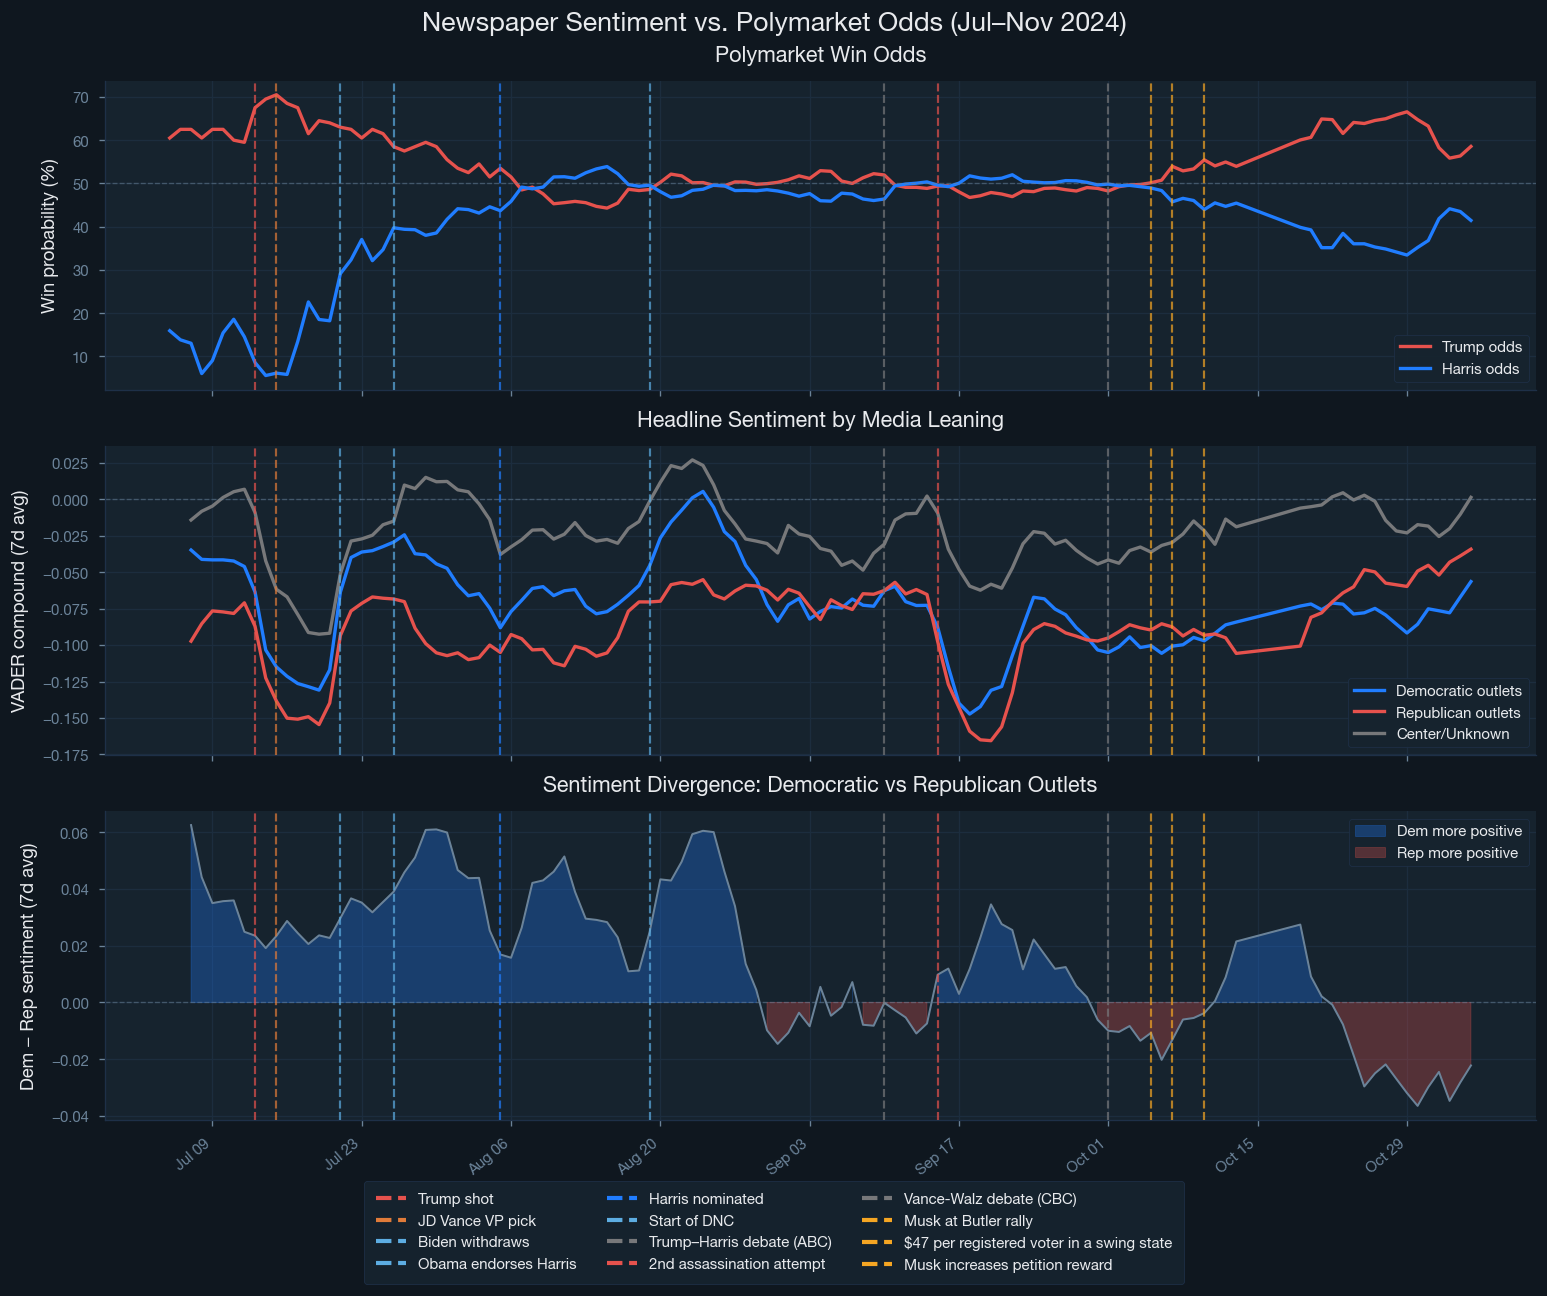

In [35]:
df['sent_divergence'] = df['vader_compound_mean_dem'] - df['vader_compound_mean_rep']
df['sent_div_7d']     = df['sent_divergence'].rolling(7, min_periods=3).mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# ─ Panel 1: Polymarket odds ────────────────────────────────────────────
ax = axes[0]
ax.plot(df['date'], df['trump_odds'],  color=C_TRUMP,  lw=2, label='Trump odds')
ax.plot(df['date'], df['harris_odds'], color=C_HARRIS, lw=2, label='Harris odds')
ax.axhline(50, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Win probability (%)')
ax.set_title('Polymarket Win Odds')
ax.legend(); fmt_xaxis(ax)

# ─ Panel 2: VADER compound by leaning ───────────────────────────────
ax = axes[1]
for col, color, label in [
    ('vader_compound_mean_dem', C_DEM, 'Democratic outlets'),
    ('vader_compound_mean_rep', C_REP, 'Republican outlets'),
    ('vader_compound_mean_cen', C_CEN, 'Center/Unknown'),
]:
    ax.plot(df['date'], df[col].rolling(7, min_periods=3).mean(),
            color=color, lw=2, label=label)
ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('VADER compound (7d avg)')
ax.set_title('Headline Sentiment by Media Leaning')
ax.legend(); fmt_xaxis(ax)

# ─ Panel 3: Dem–Rep sentiment divergence ──────────────────────────────
ax = axes[2]
ax.fill_between(df['date'], df['sent_div_7d'], 0,
                where=df['sent_div_7d'] >= 0, alpha=0.3, color=C_DEM, label='Dem more positive')
ax.fill_between(df['date'], df['sent_div_7d'], 0,
                where=df['sent_div_7d'] < 0,  alpha=0.3, color=C_REP, label='Rep more positive')
ax.plot(df['date'], df['sent_div_7d'], color=TEXT_MUTED, lw=1.2)
ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Dem − Rep sentiment (7d avg)')
ax.set_title('Sentiment Divergence: Democratic vs Republican Outlets')
ax.legend(); fmt_xaxis(ax)

for ax in axes:
    add_events(ax)

fig.suptitle('Newspaper Sentiment vs. Polymarket Odds (Jul–Nov 2024)')
plt.tight_layout()
fig.subplots_adjust(bottom=0.14)
event_legend(fig)
plt.show()


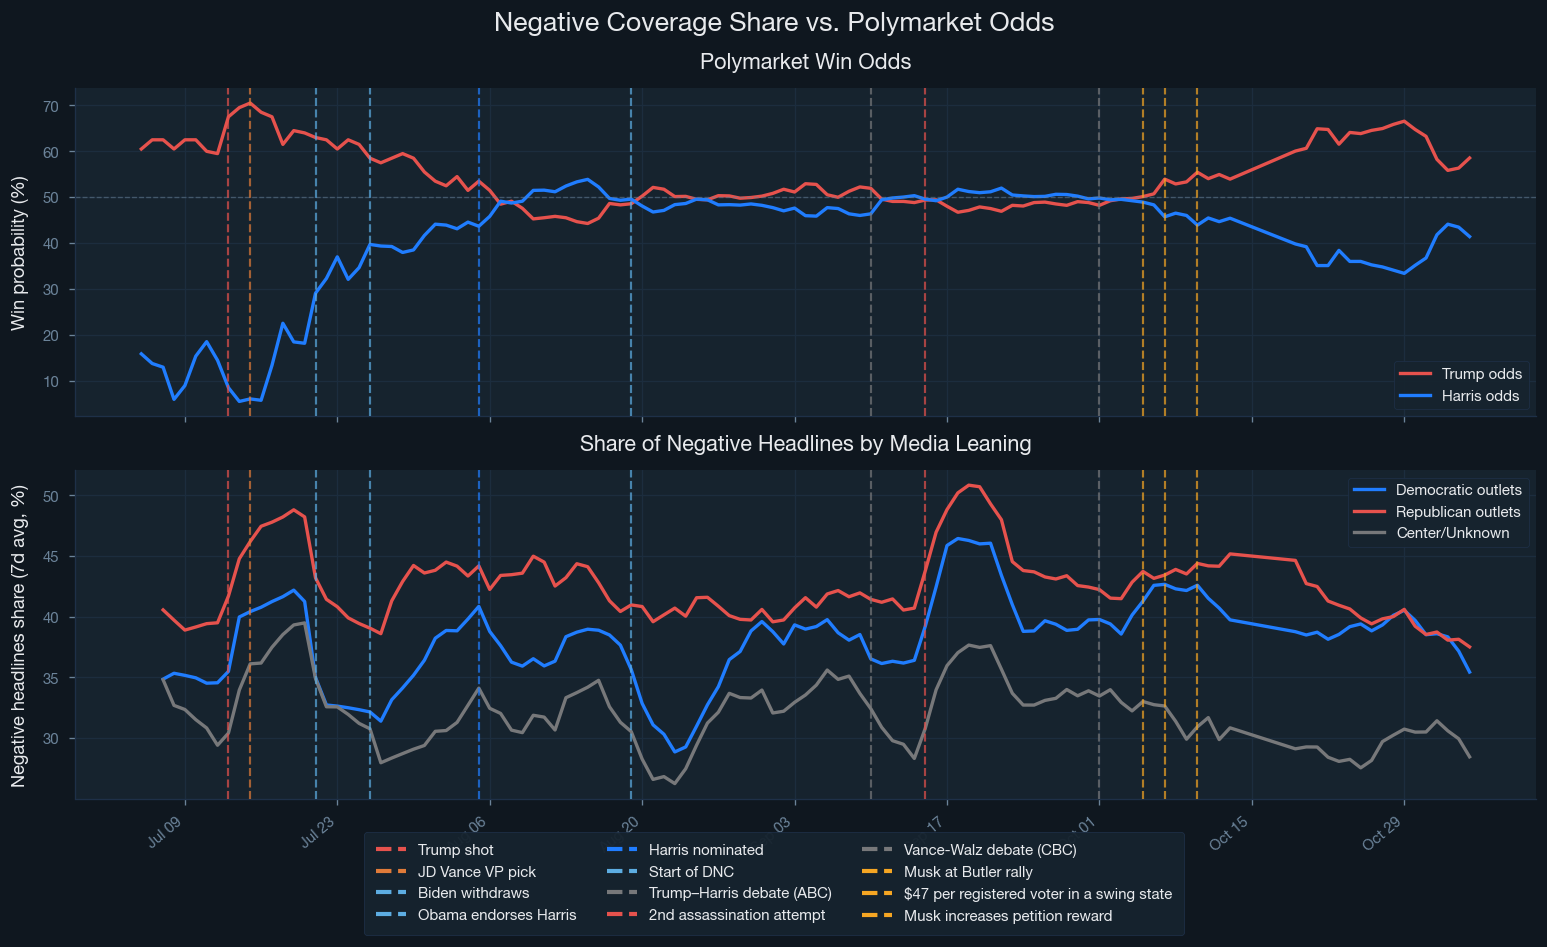

In [36]:
# ── Negative headline share per leaning vs Polymarket odds ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(df['date'], df['trump_odds'],  color=C_TRUMP,  lw=2, label='Trump odds')
ax.plot(df['date'], df['harris_odds'], color=C_HARRIS, lw=2, label='Harris odds')
ax.axhline(50, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Win probability (%)')
ax.set_title('Polymarket Win Odds')
ax.legend(); fmt_xaxis(ax)

ax = axes[1]
for col, color, label in [
    ('vader_neg_share_dem', C_DEM, 'Democratic outlets'),
    ('vader_neg_share_rep', C_REP, 'Republican outlets'),
    ('vader_neg_share_cen', C_CEN, 'Center/Unknown'),
]:
    ax.plot(df['date'], df[col].rolling(7, min_periods=3).mean() * 100,
            color=color, lw=2, label=label)
ax.set_ylabel('Negative headlines share (7d avg, %)')
ax.set_title('Share of Negative Headlines by Media Leaning')
ax.legend(); fmt_xaxis(ax)

for ax in axes:
    add_events(ax)

fig.suptitle('Negative Coverage Share vs. Polymarket Odds')
plt.tight_layout()
fig.subplots_adjust(bottom=0.16)
event_legend(fig)
plt.show()


### Key Takeaways Newspaper Sentiment × Polymarket Odds


# 4. Newspaper Emotions × Financial Markets


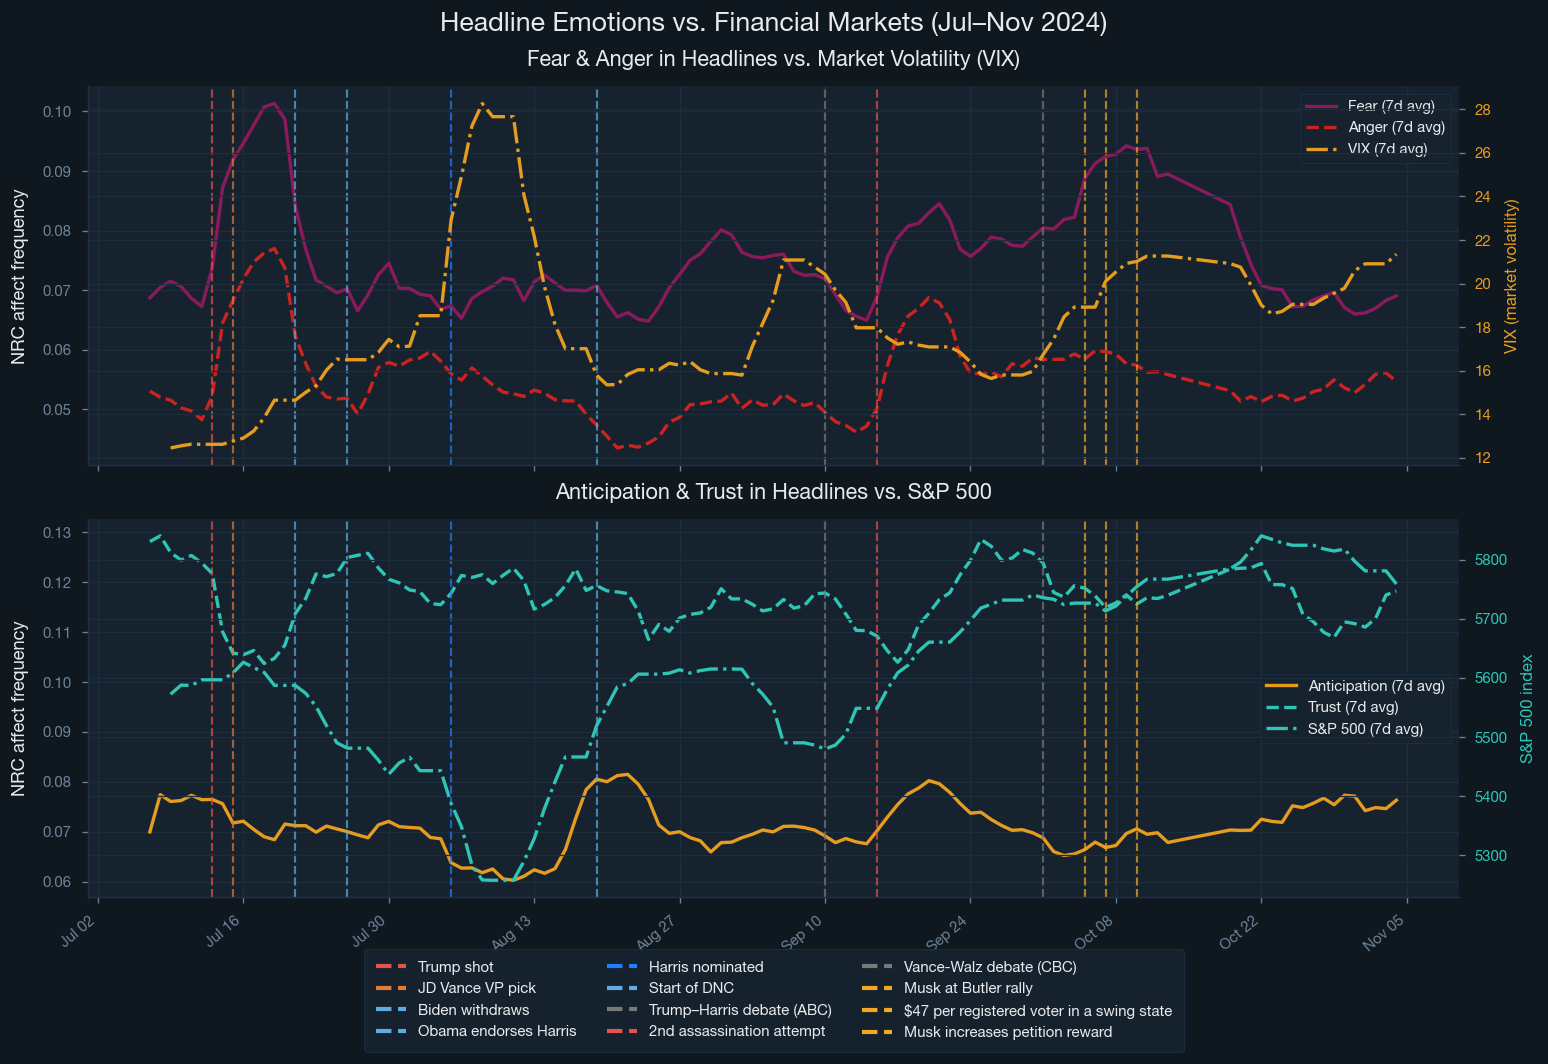

In [37]:
# ── Fear + Anger (averaged across leanings) vs VIX ─────────────────────────
df['fear_avg']  = df[['nrc_fear_dem',  'nrc_fear_rep',  'nrc_fear_cen']].mean(axis=1)
df['anger_avg'] = df[['nrc_anger_dem', 'nrc_anger_rep', 'nrc_anger_cen']].mean(axis=1)
df['trust_avg'] = df[['nrc_trust_dem', 'nrc_trust_rep', 'nrc_trust_cen']].mean(axis=1)
df['antic_avg'] = df[['nrc_anticipation_dem', 'nrc_anticipation_rep', 'nrc_anticipation_cen']].mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Fear & Anger vs VIX ────────────────────────────────────────────────────────
ax1 = axes[0]; ax2 = ax1.twinx()
ax1.plot(df['date'], df['fear_avg'].rolling(7, min_periods=3).mean(),
         color=C_FEAR, lw=2, label='Fear (7d avg)')
ax1.plot(df['date'], df['anger_avg'].rolling(7, min_periods=3).mean(),
         color=C_ANGER, lw=2, ls='--', label='Anger (7d avg)')
ax2.plot(df['date'], df['VIX'].rolling(7, min_periods=3).mean(),
         color=C_VIX, lw=2, label='VIX (7d avg)', ls='-.')
ax1.set_ylabel('NRC affect frequency')
ax1.set_title('Fear & Anger in Headlines vs. Market Volatility (VIX)')
style_twin(ax2, ylabel='VIX (market volatility)', ylabel_color=C_VIX)
ax2.tick_params(axis='y', labelcolor=C_VIX)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
fmt_xaxis(ax1); add_events(ax1)

# Anticipation & Trust vs S&P 500 ───────────────────────────────────────────
ax1 = axes[1]; ax2 = ax1.twinx()
ax1.plot(df['date'], df['antic_avg'].rolling(7, min_periods=3).mean(),
         color=C_VIX, lw=2, label='Anticipation (7d avg)')
ax1.plot(df['date'], df['trust_avg'].rolling(7, min_periods=3).mean(),
         color=C_MARKET, lw=2, ls='--', label='Trust (7d avg)')
ax2.plot(df['date'], df['SP500'].rolling(7, min_periods=3).mean(),
         color=C_MARKET, lw=2, label='S&P 500 (7d avg)', ls='-.')
ax1.set_ylabel('NRC affect frequency')
ax1.set_title('Anticipation & Trust in Headlines vs. S&P 500')
style_twin(ax2, ylabel='S&P 500 index', ylabel_color=C_MARKET)
ax2.tick_params(axis='y', labelcolor=C_MARKET)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
fmt_xaxis(ax1); add_events(ax1)

fig.suptitle('Headline Emotions vs. Financial Markets (Jul–Nov 2024)')
plt.tight_layout()
fig.subplots_adjust(bottom=0.16)
event_legend(fig)
plt.show()


### Key Takeaways Newspaper Emotions × Financial Markets


# 9. NRC 8-Emotion Profile — Full Timeline (Bluesky)


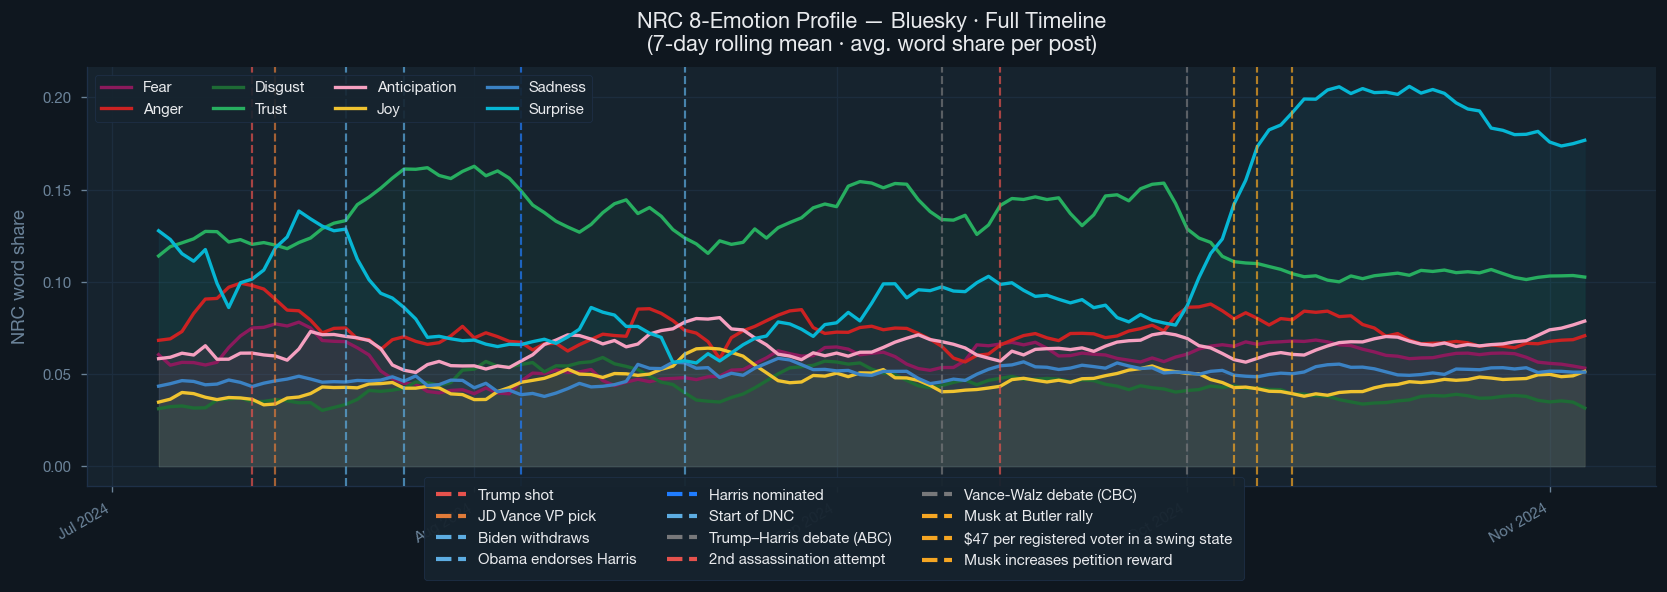

trust           0.1292
surprise        0.1136
anger           0.0739
anticipation    0.0650
fear            0.0582
sadness         0.0496
joy             0.0459
disgust         0.0430


In [38]:
EMOT_COLORS_8 = {
    'fear':         C_FEAR,
    'anger':        C_ANGER,
    'disgust':      C_DISGUST,
    'trust':        C_TRUST,
    'anticipation': C_ANTICIPATION,
    'joy':          C_JOY,
    'sadness':      C_SADNESS,
    'surprise':     '#06B6D4',
}
ALL_EMOTIONS = list(EMOT_COLORS_8.keys())

# Load Bluesky NRC sentiment data (all 8 emotions per post)
bsky_sent = pd.read_csv(SILVER / 'bluesky/sentiment_bluesky.csv', parse_dates=['date'])
bsky_sent['date'] = pd.to_datetime(bsky_sent['date'], utc=True).dt.normalize().dt.tz_localize(None)

daily_bsky = bsky_sent.groupby('date')[ALL_EMOTIONS].mean()

ROLL = 7
fig, ax = plt.subplots(figsize=(14, 5))
for emot in ALL_EMOTIONS:
    smooth = daily_bsky[emot].rolling(ROLL, center=True, min_periods=3).mean()
    ax.plot(daily_bsky.index, smooth,
            color=EMOT_COLORS_8[emot], linewidth=2.0, label=emot.capitalize())
    ax.fill_between(daily_bsky.index, smooth,
                    color=EMOT_COLORS_8[emot], alpha=0.06)

add_events(ax)
ax.set_title("NRC 8-Emotion Profile — Bluesky · Full Timeline\n"
             "(7-day rolling mean · avg. word share per post)",
             color=TEXT_PRIMARY, pad=10)
ax.set_ylabel("NRC word share", color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(frameon=True, ncol=4, labelcolor=TEXT_PRIMARY, loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
event_legend(fig)
plt.show()

print(daily_bsky[ALL_EMOTIONS].mean().sort_values(ascending=False)
      .rename("overall mean").round(4).to_string())

# 10. NRC 8-Emotion Profile — Full Timeline (News)


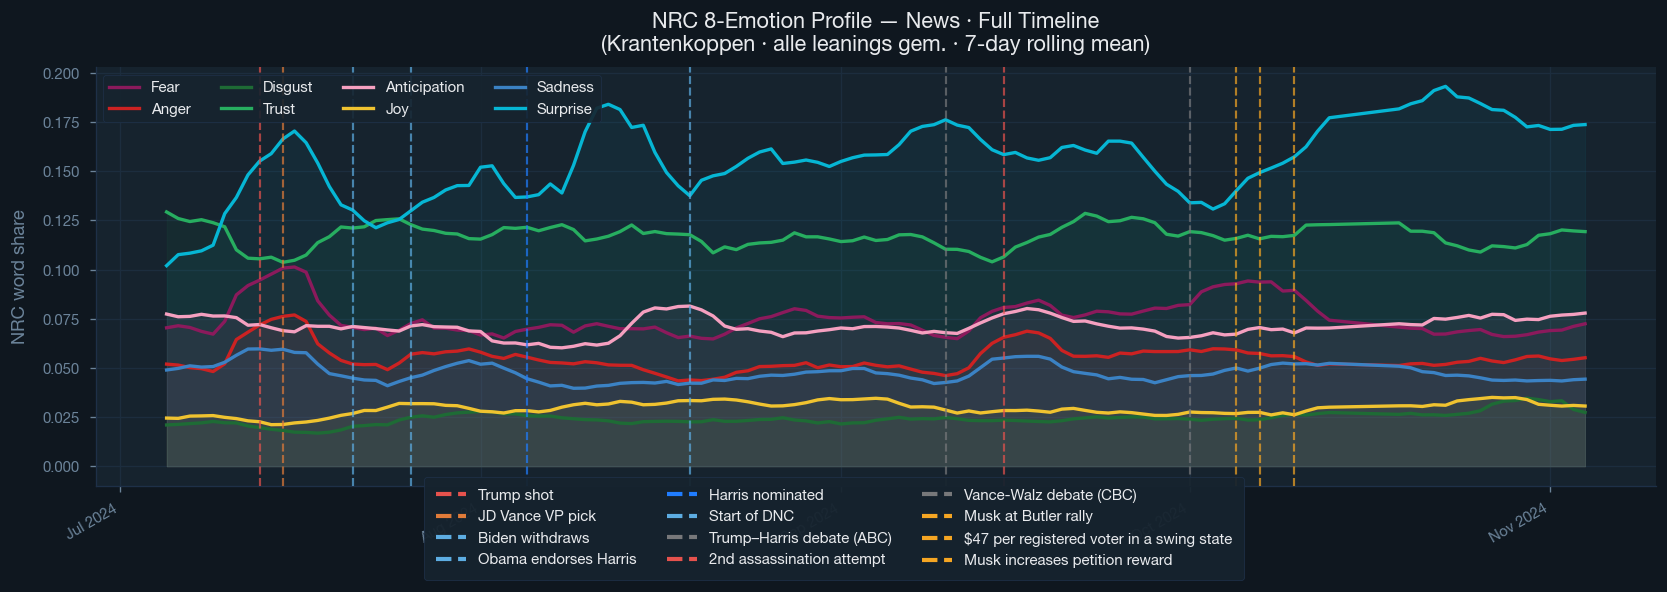

surprise        0.1549
trust           0.1171
fear            0.0753
anticipation    0.0712
anger           0.0550
sadness         0.0476
joy             0.0294
disgust         0.0243


In [39]:
# Bereken gemiddelden over leanings voor alle 8 emoties
for e in ['fear', 'anger', 'disgust', 'trust', 'anticipation', 'joy', 'sadness', 'surprise']:
    cols = [f'nrc_{e}_dem', f'nrc_{e}_rep', f'nrc_{e}_cen']
    available = [c for c in cols if c in df.columns]
    if available:
        df[f'news_{e}_avg'] = df[available].mean(axis=1)

NEWS_EMOT_COLS = {e: f'news_{e}_avg' for e in ALL_EMOTIONS if f'news_{e}_avg' in df.columns}

fig, ax = plt.subplots(figsize=(14, 5))
for emot, col in NEWS_EMOT_COLS.items():
    smooth = df[col].rolling(ROLL, center=True, min_periods=3).mean()
    ax.plot(df['date'], smooth,
            color=EMOT_COLORS_8[emot], linewidth=2.0, label=emot.capitalize())
    ax.fill_between(df['date'], smooth,
                    color=EMOT_COLORS_8[emot], alpha=0.06)

add_events(ax)
ax.set_title("NRC 8-Emotion Profile — News · Full Timeline\n"
             "(Krantenkoppen · alle leanings gem. · 7-day rolling mean)",
             color=TEXT_PRIMARY, pad=10)
ax.set_ylabel("NRC word share", color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(frameon=True, ncol=4, labelcolor=TEXT_PRIMARY, loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
event_legend(fig)
plt.show()

print(pd.Series({e: df[c].mean() for e, c in NEWS_EMOT_COLS.items()},
                name="overall mean").sort_values(ascending=False).round(4).to_string())